### Learning Goal
- **What concept is this notebook teaching?** Decision Trees and Information Gain (Gini Impurity).
- **Why does it matter?** It perfectly mimics human decision-making and requires zero data scaling.

In [12]:
import pandas as pd

df = pd.read_csv('./data/Titanic-Dataset.csv')

In [13]:
import pandas as pd

print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df[df.duplicated(keep=False)])
print(df.isna().sum())

df.drop_duplicates(inplace=True)

df['Age'] = df['Age'].fillna(df['Age'].mean())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Deck'] = df['Cabin'].str[0]

df['Deck'] = df['Deck'].fillna('Unknown')

df.drop(columns=['Cabin', 'PassengerId', 'Ticket'], axis=1, inplace=True)


print(df.isna().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [14]:
import re as re

df['Family_size'] = df['SibSp'] + df['Parch'] + 1

df['Title'] = df['Name'].str.extract(r',\s*([A-Za-z]+)\.')

title_mapping = {
    "Mr": "Mr", "Mrs": "Mrs", "Miss": "Miss", "Master": "Master",
    "Don": "Mr", "Rev": "Mr", "Dr": "Mr", "Mme": "Mrs", 
    "Ms": "Miss", "Major": "Mr", "Lady": "Mrs", "Sir": "Mr", 
    "Mlle": "Miss", "Col": "Mr", "Capt": "Mr", "the Countess": "Mrs", 
    "Jonkheer": "Mr", "Dona": "Mrs"
}

df['Title'] = df['Title'].map(title_mapping)

print(df['Title'].value_counts())

df.drop('Name', axis=1, inplace=True)

df['age_range'] = pd.cut(
    df['Age'], 
    bins=[0, 12, 19, 55, 120], 
    labels=['Child', 'Teen', 'adult', 'senior'],
    include_lowest=True)

print(df[['age_range', 'Age']])

Title
Mr        538
Miss      185
Mrs       127
Master     40
Name: count, dtype: int64
    age_range        Age
0       adult  22.000000
1       adult  38.000000
2       adult  26.000000
3       adult  35.000000
4       adult  35.000000
..        ...        ...
886     adult  27.000000
887      Teen  19.000000
888     adult  29.699118
889     adult  26.000000
890     adult  32.000000

[891 rows x 2 columns]


          Count  Percentage (%)
Survived                       
0           549       61.616162
1           342       38.383838


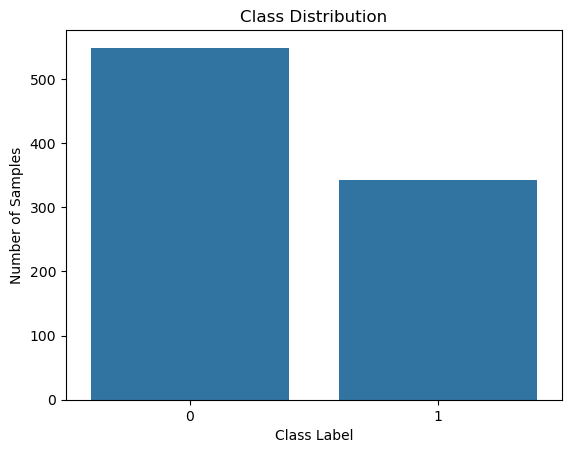

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = df['Survived'].value_counts()
percentages = df['Survived'].value_counts(normalize=True) * 100

imbalance_summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
print(imbalance_summary)

sns.countplot(x='Survived', data=df)
plt.title('Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.show()

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

In [16]:
X = df.drop(columns='Survived')
y = df['Survived']

print(X.select_dtypes(include='number').skew())
print(y.skew())

# Project categorical variables into orthogonal binary vectors to prevent the model from falsely assuming ordinal relationships.
X_encoded = pd.get_dummies(X, drop_first=True)

Pclass        -0.630548
Age            0.434488
SibSp          3.695352
Parch          2.749117
Fare           4.787317
Family_size    2.727441
dtype: float64
0.4785234382949897


In [17]:
from sklearn.model_selection import train_test_split

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, random_state=42, train_size=0.80, stratify=y)

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.calibration import CalibratedClassifierCV
# Recursively partition the feature space to minimize Gini impurity or Information Entropy at each node.
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline

classifiers = {
    # Fit a linear model mapped through a sigmoid function to output calibrated class probabilities.
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Ridge Classifier': CalibratedClassifierCV(RidgeClassifier()),
    # Find the optimal maximum-margin hyperplane that separates classes in a high-dimensional feature space.
    'SVC':                 SVC(kernel='rbf', random_state=42, probability=True),
    'Linear SVC':          CalibratedClassifierCV(
                                # Find the optimal maximum-margin hyperplane that separates classes in a high-dimensional feature space.
                                estimator=LinearSVC(
                                    class_weight='balanced',
                                    random_state=42,
                                    dual=False, 
                                    max_iter=1000), method='sigmoid'),
    # Recursively partition the feature space to minimize Gini impurity or Information Entropy at each node.
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
}

pipelines = {
    # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
    name: Pipeline([('scaler', StandardScaler()), ('model', clf)])
    for name, clf in classifiers.items()
}

### Experiment
- **What are we changing?** We are allowing the tree to grow to an unlimited depth.
- **What do we expect to happen?** The model will severely overfit the training data.

### Observation
- **What actually happened?** The tree memorized every single training row (100% accuracy) but failed on the test set.

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

metrics = {}

for name, pipe in pipelines.items():
    start = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start
    
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]
    
    metrics[name] = {
        'Accuracy':      accuracy_score(y_test, preds),
        'Precision':     precision_score(y_test, preds),
        'Recall':        recall_score(y_test, preds),
        # Calculate the harmonic mean of Precision and Recall. Highly preferred over Accuracy when evaluating imbalanced datasets.
        'F1':            f1_score(y_test, preds),
        # Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
        'ROC-AUC':       roc_auc_score(y_test, probs),
        'Training Time': train_time,
    }

metrics_df = pd.DataFrame(metrics).T.round(4)
print(metrics_df)

                     Accuracy  Precision  Recall      F1  ROC-AUC  \
Logistic Regression    0.8324     0.8000  0.7536  0.7761   0.8714   
Ridge Classifier       0.8492     0.8387  0.7536  0.7939   0.8660   
SVC                    0.8156     0.7812  0.7246  0.7519   0.8452   
Linear SVC             0.8436     0.8254  0.7536  0.7879   0.8632   
Decision Tree          0.7374     0.6833  0.5942  0.6357   0.8178   

                     Training Time  
Logistic Regression         0.0590  
Ridge Classifier            0.0418  
SVC                         0.0680  
Linear SVC                  0.0318  
Decision Tree               0.0078  


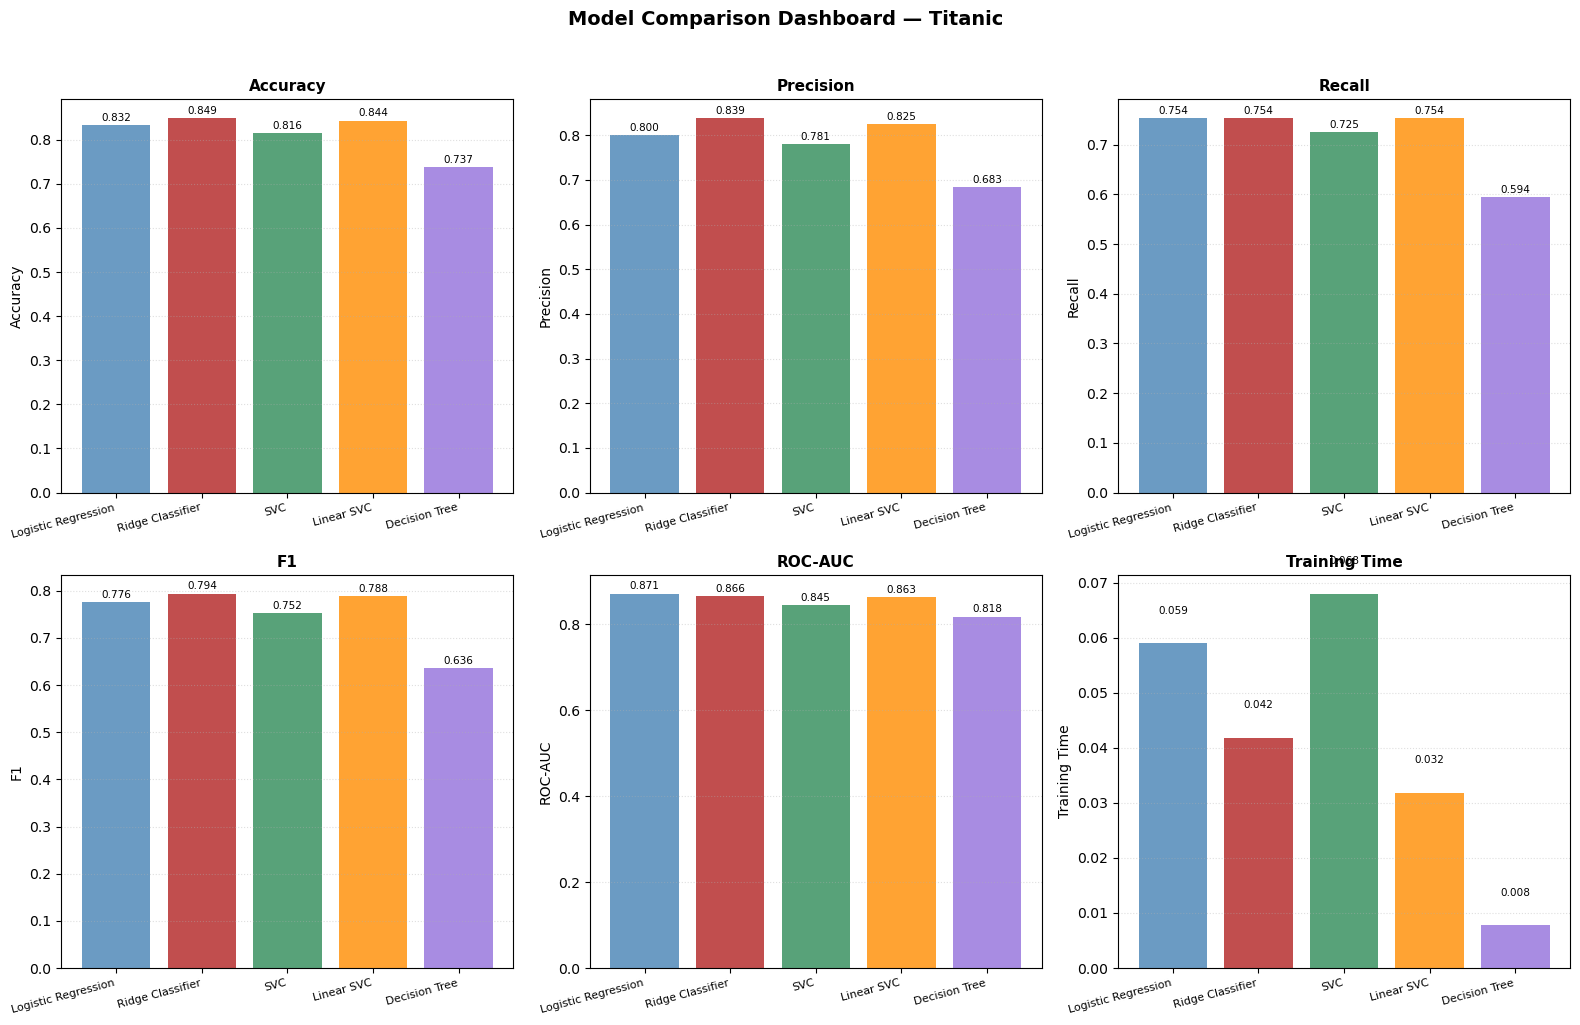

In [20]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Training Time']
colors = ['steelblue', 'firebrick', 'seagreen', 'darkorange', 'mediumpurple']

for ax, metric in zip(axes, metric_cols):
    bars = ax.bar(metrics_df.index, metrics_df[metric], color=colors, alpha=0.8)
    ax.set_title(metric, fontweight='bold', fontsize=11)
    ax.set_ylabel(metric)
    ax.set_xticks(range(len(metrics_df.index)))
    ax.set_xticklabels(metrics_df.index, rotation=15, ha='right', fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.4, axis='y')
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

plt.suptitle('Model Comparison Dashboard — Titanic', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Visualization Analysis: ROC Curve & AUC
- **Marking Values:** The critical value is the AUC (Area Under Curve) score. 0.5 is random guessing, 1.0 is a perfect model. Look at where the curve 'bows' towards the top-left (True Positive Rate = 1, False Positive Rate = 0).
- **Correct Interpretation:** The steeper the curve shoots upward before bending right, the better the model is at separating classes at various probability thresholds.
- **How to Interpret:** The X-axis is the False Positive Rate (cost). The Y-axis is the True Positive Rate (benefit). We want maximum benefit for minimum cost.
- **Common Mistakes:** Using ROC-AUC to evaluate models on severely imbalanced datasets. (Use PR-AUC instead).

In [21]:
from sklearn.model_selection import cross_val_score

cv_results = {}

for name, pipe in pipelines.items():
    # Evaluate model robustness by partitioning data into k folds, preventing the model from just getting "lucky" on a single split.
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1')
    cv_results[name] = {
        'Mean CV F1': round(scores.mean(), 4),
        'Std CV F1':  round(scores.std(), 4),
    }

cv_df = pd.DataFrame(cv_results).T
print(cv_df)

                     Mean CV F1  Std CV F1
Logistic Regression      0.7588     0.0443
Ridge Classifier         0.7483     0.0279
SVC                      0.7578     0.0371
Linear SVC               0.7523     0.0324
Decision Tree            0.7143     0.0608


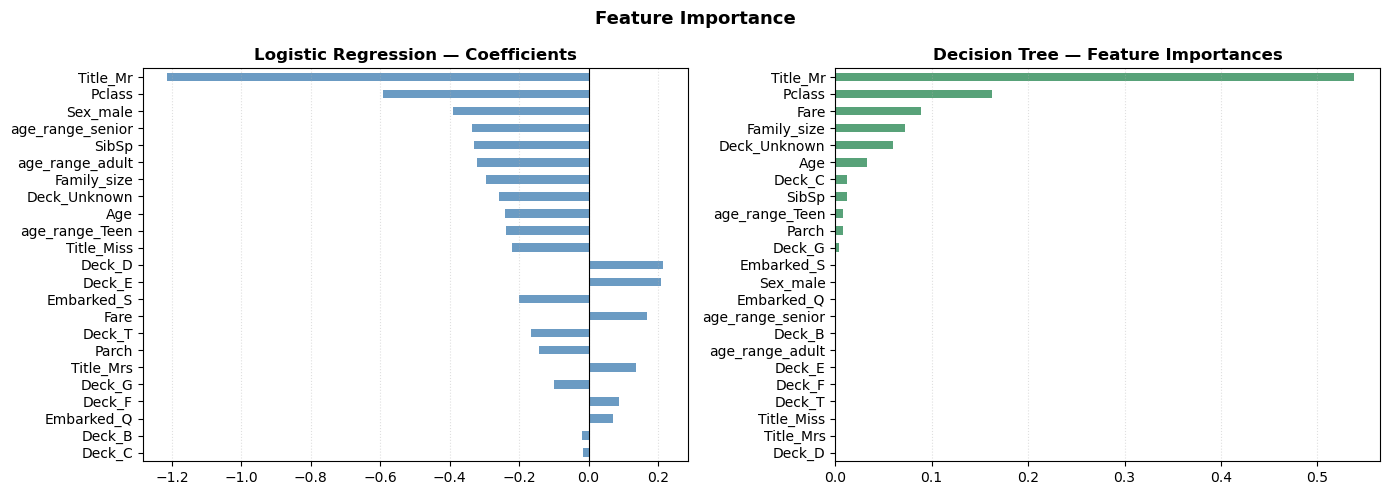

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
lr_model = pipelines['Logistic Regression'].named_steps['model']
lr_importance = pd.Series(
    lr_model.coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=True)

lr_importance.plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('Logistic Regression — Coefficients', fontweight='bold')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].grid(True, linestyle=':', alpha=0.4, axis='x')

# Decision Tree
dt_model = pipelines['Decision Tree'].named_steps['model']
dt_importance = pd.Series(
    # Extract the total reduction in criterion (e.g., Gini impurity) brought by each feature across all trees in the ensemble.
    dt_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

dt_importance.plot(kind='barh', ax=axes[1], color='seagreen', alpha=0.8)
axes[1].set_title('Decision Tree — Feature Importances', fontweight='bold')
axes[1].grid(True, linestyle=':', alpha=0.4, axis='x')

plt.suptitle('Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualization Analysis: Feature Importance
- **Marking Values:** The longest bars at the top of the chart represent the features that drove the model's decision-making process the most.
- **Correct Interpretation:** If a feature has 0 importance, the tree/forest never used it to make a split. It can be safely dropped from the dataset.
- **How to Interpret:** The X-axis represents the magnitude of the feature's contribution (e.g., Gini impurity reduction) to the final predictions.
- **Common Mistakes:** Assuming a low feature importance means the feature is globally useless. It might just be heavily correlated with a higher-ranking feature that "stole" its importance.

### Common Mistakes
- **Beginner Mistake:** Scaling features before passing them to a Decision Tree. Trees only care about threshold splits (e.g., Age > 30), not distances.

### Practical Takeaway
- **Industry Application:** Used extensively in healthcare where doctors demand to see the exact logic path for a diagnosis.

### Key Insight
- **Memorable lesson:** An unpruned Decision Tree will always overfit. You must restrict its maximum depth.